<p class="mlx-kicker">Part III &middot; Training recipe &middot; Chapter 9</p>

# 9. Optimizer: from SGD with momentum to Muon

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 8 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, gradients and gradient descent</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/09-optimizer/index.ipynb)

![The three generations of optimizer. Each column highlights the one part that is new: a velocity that sums past gradients, a separate step size for every weight taken from a running average of squared gradients, and a matrix update whose singular values are all pushed to about one.](figures/optimizer-lineage.svg)

## What changed, and why it works

Backpropagation gives one number per weight: the gradient, the direction in which the loss rises fastest. The optimizer decides how far to move each weight given that number and everything it has seen before. That choice matters because the loss surface of a network is badly shaped: some directions are steep and others nearly flat, so one step size cannot suit all of them. Each generation in Figure 9.1 answers that problem differently, and the question that runs through this chapter is: **why does a separate step size per weight help, and when does it hurt?**

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; SGD + momentum</p><h3>A velocity that remembers</h3><p><b>What changed.</b> Plain gradient descent steps along the current gradient. Momentum keeps a running sum of past gradients, a velocity, and steps along that instead. One global step size still applies to every weight.</p><p><b>Why it works.</b> In a long, narrow valley the gradient points mostly across the valley, so plain descent bounces from wall to wall. The bounces alternate in sign and cancel in the velocity, while the small, consistent push along the valley floor adds up. The optimizer gains speed exactly in the flat direction that was slow.</p><p class="mlx-why__run">Our run, valley 100 times steeper across than along: loss after 100 steps 0.22 for SGD, 0.000011 with momentum</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Adam, AdamW</p><h3>A step size for each weight</h3><p><b>What changed.</b> Adam divides each weight's averaged gradient by the root mean square of its recent gradients, so every weight gets its own step size. AdamW then moves weight decay outside that division.</p><p><b>Why it works.</b> When the steep and flat directions line up with individual weights, dividing by each weight's gradient scale makes all of them move at a similar rate, which is the fix the valley needed. Weight decay added to the gradient would be divided too, so weights with small gradients would be decayed hardest; AdamW applies decay directly, at the same rate for every weight.</p><p class="mlx-why__run">Our runs: valley aligned with the weights, Adam 2&times;10<sup>-8</sup> against 2.3 for momentum; turned 45&deg;, Adam 5.8. On the language model, Adam with L2 decay 3.360, AdamW 2.006</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Muon</p><h3>Orthogonalize the matrix update</h3><p><b>What changed.</b> For each weight matrix, Muon takes the momentum of its gradient and replaces it with the nearest orthogonal matrix, computed with five Newton-Schulz iterations. Vectors such as embeddings and norm gains keep AdamW.</p><p><b>Why it works.</b> A weight matrix's gradient is usually dominated by a few directions. Orthogonalizing keeps the directions but sets every singular value to about one, so the rare directions get as large a step as the dominant one. Unlike Adam's per-weight scaling, this does not depend on which basis the weights happen to be stored in.</p><p class="mlx-why__run">Our runs, best learning rate each: SGD 2.175, AdamW 2.006, Muon 1.904</p></section>
</div>

Read left to right, the optimizer learns more about the shape of the loss: first a running memory of the gradient, then a scale per weight, then the structure of a whole matrix. Each step buys speed, and each makes a new assumption about which directions are steep. The steps below rebuild each optimizer from scratch and test where that assumption holds and where it breaks.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1951, 1964 | SGD, heavy-ball momentum | **major** | step along a running sum of gradients (Robbins and Monro; Polyak) |
| 2011 | AdaGrad | minor | a step size per weight, from the sum of all past squared gradients |
| 2012 | RMSProp | minor | an exponential average instead of a sum, so step sizes can recover |
| 2014 | Adam | **major** | momentum plus RMSProp plus a bias correction; the default for a decade |
| 2017 | AdamW | minor | weight decay applied directly, not through the gradient; standard for LLMs |
| 2018, 2023 | Shampoo, Lion | minor | a matrix preconditioner per layer; the sign of the momentum |
| 2024 | Muon | **major** | orthogonalized momentum for weight matrices; used to train Kimi K2 (2025) |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| SGD to SGD + momentum | zig-zagging in narrow valleys, noisy gradients | speed along flat directions, averaged noise |
| momentum to AdaGrad and RMSProp | weights whose gradients differ in scale by orders of magnitude, such as rare embeddings | a step size per weight, far less tuning |
| RMSProp to Adam | wanting momentum too, and a biased start | one robust default for almost every network |
| Adam to AdamW | L2 decay is distorted by the per-weight scaling | decay that does what it says, and tuning it no longer moves the best learning rate |
| AdamW to Muon (and Shampoo) | diagonal scaling ignores the structure of a weight matrix | updates that do not depend on the basis, and fewer steps to a given loss |

Read top to bottom, each optimizer assumes a little more about the geometry of the loss and spends a little more memory or compute to exploit it. Momentum assumes the gradient is consistent over time. Adam assumes the steep and flat directions line up with individual weights. Muon assumes the useful unit is the weight matrix and its singular directions. Each assumption pays off when it holds and costs you when it does not, which is the answer to this chapter's question in one sentence.

**Still open:** why Adam beats SGD so clearly on Transformers but not on convolutional networks (heavy-tailed gradient noise and very different curvature in different blocks are the leading explanations); whether Muon's advantage holds at the largest scales and over long training runs; and how the best learning rate, batch size and schedule change with the optimizer.

## Run it yourself

The steps share this setup. The first two steps run on two-dimensional toy losses, where we can draw every step an optimizer takes. The last three train the chapter 1 language model on TinyShakespeare, with every optimizer written from scratch in about 10 to 25 lines. Everything runs on a laptop CPU.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import math, time
from mlexp.transformer import TransformerLM

torch.set_num_threads(1)  # we ran with one thread; raise it on your own machine
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (major): SGD and momentum

#### The idea

**Gradient descent** moves every weight a small step against its gradient: `w <- w - lr * g`. **Stochastic** gradient descent (SGD) does the same with a gradient computed on a small random batch, which is noisy but cheap (Robbins and Monro, 1951).

The trouble is the shape of the loss. Near a minimum it looks like a bowl, but rarely a round one: it is usually a long, narrow valley, steep across and nearly flat along. The step size must be small enough not to overshoot in the steep direction, so it is far too small for the flat one. On a quadratic whose steepest direction is `\(\kappa\)` times steeper than its flattest, plain gradient descent needs roughly `\(\kappa\)` steps to make progress along the flat direction. `\(\kappa\)` is called the **condition number**.

**Momentum** (Polyak, 1964) keeps a velocity: a running sum of past gradients, each older one weighted by a factor `\(\mu\)` (typically 0.9). Gradients that keep changing sign, the bouncing across the valley, cancel in the sum. Gradients that keep pointing the same way, the slope along the floor, add up to about `\(1/(1-\mu)\)` times their size. On a quadratic, well-tuned momentum needs roughly `\(\sqrt{\kappa}\)` steps instead of `\(\kappa\)`. **[established]** Sutskever et al. (2013) showed that momentum, with a good initialization, was enough to train deep networks that had been thought to need second-order methods.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: SGD with momentum</p><div class="mlx-eq">$$v_t = \mu\, v_{t-1} + g_t, \qquad w_t = w_{t-1} - \eta\, v_t$$</div><p class="mlx-eq__where">\(g_t\) is the gradient at step \(t\), \(v_t\) the velocity, \(\mu\) the momentum factor and \(\eta\) the learning rate, the same for every weight. With \(\mu = 0\) this is plain SGD.</p></div>

#### Minimal implementation

Every optimizer in this chapter subclasses `torch.optim.Optimizer`, which only stores the parameter groups and a per-parameter `state` dict. The update rule itself is ours.

In [3]:
class SGDMomentum(torch.optim.Optimizer):
    """SGD with heavy-ball momentum: step along a decaying sum of past gradients."""

    def __init__(self, params, lr=0.1, momentum=0.9):
        super().__init__(params, dict(lr=lr, momentum=momentum))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                v = self.state[p].setdefault("velocity", torch.zeros_like(p))
                v.mul_(group["momentum"]).add_(p.grad)  # v = mu * v + g
                p.add_(v, alpha=-group["lr"])  # w = w - lr * v

#### Experiment: a narrow valley

We drop each optimizer into the quadratic valley `f(x, y) = (x² + κ y²) / 2` with κ = 100 and let it take 100 steps. For a fair race, each optimizer gets its best learning rate from a grid of 20 values, and the plot shows that best run.

In [4]:
def quadratic(kappa, angle_deg=0.0):
    """A quadratic valley kappa times steeper across than along, turned by angle_deg."""
    a = math.radians(angle_deg)
    R = torch.tensor([[math.cos(a), -math.sin(a)], [math.sin(a), math.cos(a)]])
    H = R @ torch.diag(torch.tensor([1.0, kappa])) @ R.T
    return (lambda w: 0.5 * w @ H @ w), R


def rosenbrock(w):
    return (1 - w[0]) ** 2 + 100 * (w[1] - w[0] ** 2) ** 2


def run(f, make_opt, start, steps):
    """Optimize a 2-D function from start; return the path, one row per step."""
    w = start.clone().requires_grad_(True)
    opt = make_opt([w])
    path = [w.detach().clone()]
    for _ in range(steps):
        opt.zero_grad()
        f(w).backward()
        opt.step()
        path.append(w.detach().clone())
    return torch.stack(path)


def best_run(f, make_opt, start, steps, lrs):
    """Try every learning rate and keep the run with the lowest final loss."""
    runs = []
    for lr in lrs:
        path = run(f, lambda p: make_opt(p, lr), start, steps)
        final = f(path[-1]).item()
        runs.append((final if math.isfinite(final) else float("inf"), lr, path))
    return min(runs, key=lambda r: r[0])


LRS = [10 ** (k / 4) for k in range(-24, 4)]  # 1e-6 to about 5.6
SGD = lambda p, lr: SGDMomentum(p, lr=lr, momentum=0.0)
MOMENTUM = lambda p, lr: SGDMomentum(p, lr=lr, momentum=0.9)

SGD             best lr 0.0178   loss after 100 steps 2.21e-01   (start 16.0)
SGD + momentum  best lr 0.0316   loss after 100 steps 1.14e-05   (start 16.0)


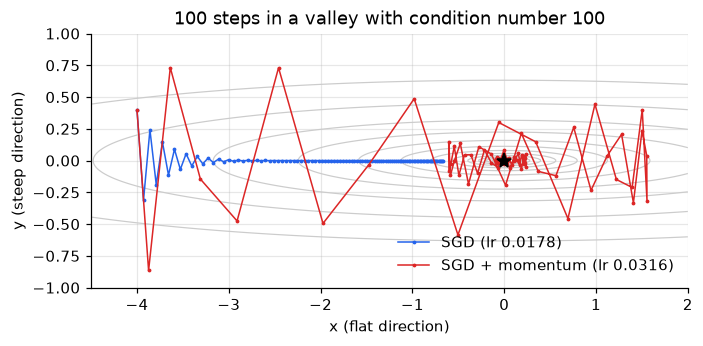

In [5]:
f, _ = quadratic(kappa=100)
start = torch.tensor([-4.0, 0.4])
lrs = LRS[:20]  # plain SGD diverges above lr = 2/kappa
res = {name: best_run(f, make, start, 100, lrs) for name, make in [("SGD", SGD), ("SGD + momentum", MOMENTUM)]}

fig, ax = plt.subplots(figsize=(7, 3))
X, Y = np.meshgrid(np.linspace(-4.5, 2, 200), np.linspace(-1, 1, 200))
ax.contour(X, Y, 0.5 * (X**2 + 100 * Y**2), levels=np.geomspace(0.01, 20, 12), colors="0.8", linewidths=0.8)
for name, (loss, lr, path) in res.items():
    ax.plot(path[:, 0], path[:, 1], marker=".", ms=3, lw=1, label=f"{name} (lr {lr:.3g})")
    print(f"{name:15s} best lr {lr:.3g}   loss after 100 steps {loss:.2e}   (start {f(start).item():.1f})")
ax.plot(0, 0, "k*", ms=10)
ax.set(xlabel="x (flat direction)", ylabel="y (steep direction)", title="100 steps in a valley with condition number 100")
ax.legend(frameon=False, loc="lower right");

Plain SGD's best learning rate is just below the limit set by the steep direction (2/κ = 0.02); any larger and it diverges. At that rate, it crawls along the flat direction and is still far from the minimum after 100 steps. Momentum overshoots at first, swings past the minimum and settles, ending about 20,000 times lower in loss. The momentum factor 0.9 is more than this valley needs, which is why the path rings; the theory's best value here would be about 0.67.

### Step 2 (major): Adam, a step size for each weight

#### The idea

Momentum still uses one learning rate for all weights. In a real network, gradient sizes differ enormously from weight to weight: the embedding of a rare character receives a gradient only when that character appears, while a weight in the output layer gets one at every step. **AdaGrad** (Duchi et al., 2011) gave each weight its own step size by dividing by the square root of the sum of its past squared gradients. Weights with small or rare gradients get large steps. Because the sum only grows, AdaGrad's steps shrink forever, so **RMSProp** (Tieleman and Hinton, 2012, in a lecture rather than a paper) replaced the sum with an exponential moving average.

**Adam** (Kingma and Ba, 2014) combines the two ideas. It keeps a moving average of the gradient, `m` (momentum), and a moving average of the squared gradient, `s`, then steps by `m / sqrt(s)`. Since both averages start at zero they are too small during the first steps, so Adam divides them by `\(1 - \beta^t\)` to correct this bias.

The ratio `m / sqrt(s)` has a useful property: it does not change when you multiply a weight's gradient by a constant. Every weight moves about `lr` per step when its gradient is consistent, whatever the gradient's size. That is what makes Adam forgiving to tune. It is also its hidden assumption: Adam rescales each **coordinate** separately, so it can only fix steep and flat directions that line up with individual weights.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: Adam</p><div class="mlx-eq">$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t, \qquad s_t = \beta_2 s_{t-1} + (1-\beta_2)\,g_t^2, \qquad w_t = w_{t-1} - \eta\,\frac{m_t / (1-\beta_1^t)}{\sqrt{s_t / (1-\beta_2^t)} + \epsilon}$$</div><p class="mlx-eq__where">All operations are element-wise, so each weight has its own \(m\) and \(s\). Typical values: \(\beta_1 = 0.9\), \(\beta_2 = 0.95\) to \(0.999\), \(\epsilon = 10^{-8}\).</p></div>

#### Minimal implementation

We write Adam with an optional weight decay that is either added to the gradient (the classic L2 penalty) or applied directly (`decoupled=True`, which is AdamW). Step 3 explains the difference.

In [6]:
class Adam(torch.optim.Optimizer):
    """Adam: momentum divided by a running RMS of the gradient, one scale per weight."""

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.95), eps=1e-8, weight_decay=0.0, decoupled=False):
        super().__init__(params, dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay, decoupled=decoupled))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            (b1, b2), lr, wd = group["betas"], group["lr"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if wd and not group["decoupled"]:
                    g = g + wd * p  # L2 penalty: decay goes through the scaling below
                state = self.state[p]
                if not state:
                    state.update(t=0, m=torch.zeros_like(p), s=torch.zeros_like(p))
                state["t"] += 1
                m, s, t = state["m"], state["s"], state["t"]
                m.lerp_(g, 1 - b1)  # m = b1 * m + (1 - b1) * g
                s.lerp_(g * g, 1 - b2)  # s = b2 * s + (1 - b2) * g^2
                m_hat, s_hat = m / (1 - b1**t), s / (1 - b2**t)
                if wd and group["decoupled"]:
                    p.mul_(1 - lr * wd)  # AdamW: shrink the weight directly
                p.addcdiv_(m_hat, s_hat.sqrt() + group["eps"], value=-lr)


def AdamW(params, **kwargs):
    return Adam(params, decoupled=True, **kwargs)

In [7]:
# Check against PyTorch's own implementations on a random problem.
for ours, theirs, kw in [(Adam, torch.optim.Adam, {}), (AdamW, torch.optim.AdamW, {"weight_decay": 0.1})]:
    torch.manual_seed(0)
    A, b = torch.randn(20, 10), torch.randn(20)
    w1, w2 = torch.zeros(10, requires_grad=True), torch.zeros(10, requires_grad=True)
    o1, o2 = ours([w1], lr=0.01, **kw), theirs([w2], lr=0.01, betas=(0.9, 0.95), **kw)
    for _ in range(50):
        for w, o in [(w1, o1), (w2, o2)]:
            o.zero_grad()
            (A @ w - b).pow(2).mean().backward()
            o.step()
    print(f"{ours.__name__:5s} max difference from torch.optim after 50 steps: {(w1 - w2).abs().max().item():.1e}")

Adam  max difference from torch.optim after 50 steps: 8.9e-08
AdamW max difference from torch.optim after 50 steps: 1.2e-07


#### Experiment: when per-weight scaling helps, and when it does not

We make the valley much harder, κ = 10,000, and race SGD, momentum and Adam twice: once with the valley aligned with the axes (the steep direction is exactly the weight `y`), and once with the same valley turned by 45°, so that steep and flat directions are now mixtures of both weights. SGD and momentum only see the geometry, so turning the valley cannot change their result. Adam sees individual weights.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The two valleys have exactly the same shape; one is turned by 45°. After 200 steps at its best learning rate, will Adam beat momentum in both, in one, or in neither?</p><details><summary>Show what happened</summary><p>Only in the aligned one. Aligned, Adam reaches a loss of 2&times;10<sup>-8</sup> against 2.3 for momentum. Turned by 45&deg;, Adam ends at 5.8, worse than momentum, whose result is unchanged.</p></details></div>

SGD             aligned 7.5e+00   turned 45° 7.5e+00
SGD + momentum  aligned 2.3e+00   turned 45° 2.3e+00
Adam            aligned 2.0e-08   turned 45° 5.8e+00


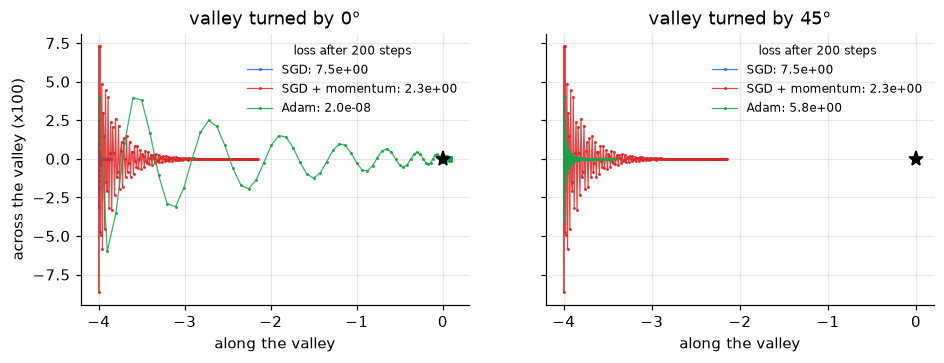

In [8]:
ADAM = lambda p, lr: Adam(p, lr=lr, betas=(0.9, 0.999))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
results = {}
for ax, angle in zip(axes, [0, 45]):
    f, R = quadratic(kappa=1e4, angle_deg=angle)
    start = R @ torch.tensor([-4.0, 0.04])  # the same start, relative to the valley
    for name, make in [("SGD", SGD), ("SGD + momentum", MOMENTUM), ("Adam", ADAM)]:
        loss, lr, path = best_run(f, make, start, 200, LRS)
        results[name, angle] = loss
        u = path @ R  # draw both panels in the valley's own axes
        ax.plot(u[:, 0], u[:, 1] * 100, lw=0.8, alpha=0.85, marker=".", ms=2, label=f"{name}: {loss:.1e}")
    ax.plot(0, 0, "k*", ms=10)
    ax.set(title=f"valley turned by {angle}°", xlabel="along the valley")
    ax.legend(frameon=False, fontsize=8, title="loss after 200 steps", title_fontsize=8)
axes[0].set_ylabel("across the valley (x100)")
for name in ["SGD", "SGD + momentum", "Adam"]:
    print(f"{name:15s} aligned {results[name, 0]:.1e}   turned 45° {results[name, 45]:.1e}")

Both panels are drawn in the valley's own axes, so they would look identical for an optimizer that does not care about orientation. SGD and momentum give the same numbers in both; plain SGD barely leaves its start and is hidden under the momentum path. Adam, aligned with the valley, divides the steep weight's large gradient and the flat weight's small gradient down to the same size and walks straight to the minimum. Turned by 45°, both weights see a mixture of steep and flat, their gradients have similar scales, and Adam's per-weight division has nothing useful to fix. It behaves like a sign-based gradient method that bounces across the valley.

Real loss surfaces lie in between. Here is the Rosenbrock function, a curved banana-shaped valley whose minimum is at (1, 1), with 1,000 steps for each optimizer.

SGD             best lr 0.0018   loss after 1000 steps 1.1e-01   distance to the minimum 6.5e-01


SGD + momentum  best lr 0.0018   loss after 1000 steps 2.3e-08   distance to the minimum 3.4e-04


Adam            best lr 0.18   loss after 1000 steps 5.2e-08   distance to the minimum 5.1e-04


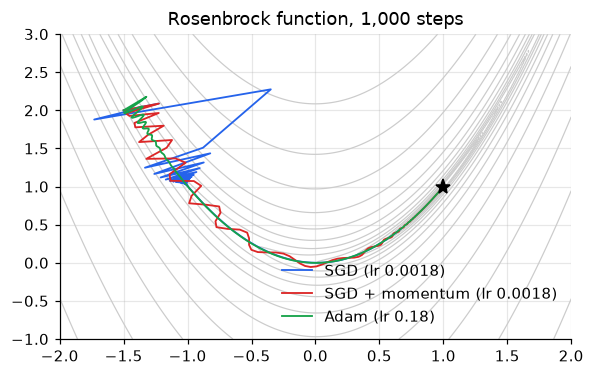

In [9]:
start = torch.tensor([-1.5, 2.0])
fig, ax = plt.subplots(figsize=(6, 3.6))
X, Y = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-1, 3, 300))
ax.contour(X, Y, (1 - X) ** 2 + 100 * (Y - X**2) ** 2, levels=np.geomspace(0.1, 2000, 14), colors="0.8", linewidths=0.8)
for name, make in [("SGD", SGD), ("SGD + momentum", MOMENTUM), ("Adam", ADAM)]:
    loss, lr, path = best_run(rosenbrock, make, start, 1000, LRS[:22])
    dist = (path[-1] - torch.tensor([1.0, 1.0])).norm().item()
    ax.plot(path[:, 0], path[:, 1], lw=1.2, label=f"{name} (lr {lr:.2g})")
    print(f"{name:15s} best lr {lr:.2g}   loss after 1000 steps {loss:.1e}   distance to the minimum {dist:.1e}")
ax.plot(1, 1, "k*", ms=10)
ax.set(xlim=(-2, 2), ylim=(-1, 3), title="Rosenbrock function, 1,000 steps")
ax.legend(frameon=False, loc="lower right");

On the Rosenbrock function both momentum and Adam reach the minimum (distances 0.00034 and 0.00051), while plain SGD stops 0.65 away. Its curved valley is aligned with the axes in some places and not in others, so here Adam's scaling neither wins nor loses clearly.

#### Why it worked: a post-mortem

**Per-weight scaling is a diagonal preconditioner.** Dividing by `sqrt(s)` is the same as multiplying the gradient by a diagonal matrix. A diagonal matrix can undo curvature that lies along the axes, but not curvature along a diagonal. Our aligned and turned valleys show the two extremes. **[established]**

**Why it helps so much in Transformers.** The curvature of a Transformer's loss is far from round, but much of the variation is between blocks of weights: embeddings, attention, feed-forward and norm gains have very different gradient scales. Zhang et al. (2024) argue that this block-to-block difference is exactly what a per-weight step size fixes and what one global SGD step size cannot. **[likely]** A second explanation is that Transformer gradient noise has heavy tails, and dividing by a running RMS tames rare huge gradients (Zhang et al., 2020). **[likely]**

**When it hurts.** Inside each weight matrix, the steep directions are mixtures of many weights, the turned valley. Adam can also generalize worse than tuned SGD on some vision tasks (Wilson et al., 2017). **[likely]** And, as the next step shows, the scaling distorts anything else you put into the gradient.

### Step 3 (minor): AdamW, decoupled weight decay

#### The idea

**Weight decay** shrinks every weight a little at each step, which keeps weights small and tends to improve generalization. With plain SGD there are two equivalent ways to write it: add an L2 penalty `\(\tfrac{\lambda}{2}\lVert w \rVert^2\)` to the loss, which adds `\(\lambda w\)` to the gradient, or multiply the weights by `\(1 - \eta\lambda\)` after each step.

Loshchilov and Hutter (2017) pointed out that with Adam the two are **not** equivalent. The L2 term `\(\lambda w\)` goes into the gradient, so it is divided by `sqrt(s)` like everything else. A weight whose loss gradient is small has a small `s`, so its decay is magnified; a weight with a large gradient barely decays. When the penalty dominates a weight's gradient, Adam's normalization turns it into a step of about `lr` towards zero at every step, whatever λ is. **AdamW** applies decay directly to the weights, outside the scaling, so every weight shrinks by the same fraction.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: L2 penalty versus decoupled decay</p><div class="mlx-eq">$$\text{Adam + L2:}\;\; w \leftarrow w - \eta\,\frac{\hat m(g + \lambda w)}{\sqrt{\hat s(g + \lambda w)}}, \qquad \text{AdamW:}\;\; w \leftarrow w - \eta\left(\frac{\hat m(g)}{\sqrt{\hat s(g)}} + \lambda w\right)$$</div><p class="mlx-eq__where">\(\hat m(\cdot)\) and \(\hat s(\cdot)\) are Adam's bias-corrected averages of whatever is fed in as the gradient. Only AdamW's decay is independent of the gradient's scale.</p></div>

#### A training loop for any optimizer

From here on we train the chapter 1 language model, at width 64 so that the whole chapter fits in a few minutes of CPU. The loop below follows `mlexp.train_lm` (warmup, cosine decay to 10%, gradient clipping at 1) but accepts any optimizer. Every run uses the same seed, the same batches and the same fixed validation batches.

In [10]:
def new_model():
    torch.manual_seed(0)
    return TransformerLM(tok.vocab_size, dim=64, n_layers=4, n_heads=4)


VAL_BATCHES = [mlexp.get_batch(val_ids, 32, 64, torch.Generator().manual_seed(100 + i)) for i in range(8)]


@torch.no_grad()
def val_loss(model):
    model.eval()
    loss = sum(model(x, y)[1].item() for x, y in VAL_BATCHES) / len(VAL_BATCHES)
    model.train()
    return loss


def train(model, opt, steps=200, eval_every=25):
    """Warmup, then cosine decay of every group's lr; returns the validation curve."""
    gen = torch.Generator().manual_seed(0)
    base_lrs = [group["lr"] for group in opt.param_groups]
    warmup = steps // 10
    hist = {"step": [], "val": []}
    for step in range(steps + 1):
        if step % eval_every == 0 or step == steps:
            hist["step"].append(step)
            hist["val"].append(val_loss(model))
        if step == steps:
            break
        frac = (step + 1) / warmup if step < warmup else 0.1 + 0.45 * (1 + math.cos(math.pi * (step - warmup) / (steps - warmup)))
        for group, lr in zip(opt.param_groups, base_lrs):
            group["lr"] = lr * frac
        x, y = mlexp.get_batch(train_ids, 32, 64, gen)
        _, loss = model(x, y)
        if not torch.isfinite(loss):  # diverged: record it and stop
            hist["step"].append(step)
            hist["val"].append(float("nan"))
            break
        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    for group, lr in zip(opt.param_groups, base_lrs):
        group["lr"] = lr
    return hist


print(f"model: {mlexp.count_params(new_model()):,} parameters")

model: 204,992 parameters


#### Experiment: what the decay actually does to the weights

We train three times with Adam at learning rate 0.01: L2 penalty with λ = 0.1, L2 with a hundred times weaker λ = 0.001, and AdamW with λ = 0.1. We then compare the size of every weight matrix with a run that has no decay at all. AdamW's λ = 0.1 is the value most LLMs use, and with this learning rate and 200 steps it should shrink weights by less than ten percent.

Adam, no decay       final val loss 2.007   (23s)


Adam + L2, λ=0.1     final val loss 3.360   (23s)


Adam + L2, λ=0.001   final val loss 2.155   (23s)


AdamW, λ=0.1         final val loss 2.006   (23s)
Adam + L2, λ=0.1     weight-matrix norms relative to no decay: median 0.00, min 0.000
Adam + L2, λ=0.001   weight-matrix norms relative to no decay: median 0.22, min 0.049
AdamW, λ=0.1         weight-matrix norms relative to no decay: median 0.92, min 0.896


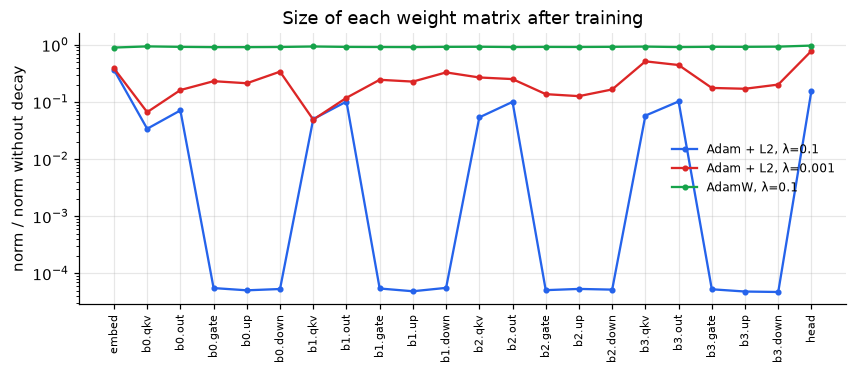

In [11]:
runs = {
    "Adam, no decay": dict(weight_decay=0.0),
    "Adam + L2, λ=0.1": dict(weight_decay=0.1),
    "Adam + L2, λ=0.001": dict(weight_decay=0.001),
    "AdamW, λ=0.1": dict(weight_decay=0.1, decoupled=True),
}
decay_models, decay_hist = {}, {}
for name, kw in runs.items():
    t0 = time.time()
    model = new_model()
    decay_hist[name] = train(model, Adam(model.parameters(), lr=0.01, **kw))
    decay_models[name] = model
    print(f"{name:20s} final val loss {decay_hist[name]['val'][-1]:.3f}   ({time.time() - t0:.0f}s)")

names = [n for n, p in decay_models["Adam, no decay"].named_parameters() if p.ndim == 2]
ref = {n: p.norm().item() for n, p in decay_models["Adam, no decay"].named_parameters()}
fig, ax = plt.subplots(figsize=(9, 3.2))
for name in list(runs)[1:]:
    params = dict(decay_models[name].named_parameters())
    ratio = [params[n].norm().item() / ref[n] for n in names]
    ax.plot(range(len(names)), ratio, marker="o", ms=3, label=name)
    print(f"{name:20s} weight-matrix norms relative to no decay: median {np.median(ratio):.2f}, min {min(ratio):.3f}")
ax.set_yscale("log")
ax.set_xticks(range(len(names)), [n.replace("blocks.", "b").replace(".weight", "").replace("attn.", "").replace("ffn.", "") for n in names], rotation=90, fontsize=7)
ax.set(ylabel="norm / norm without decay", title="Size of each weight matrix after training")
ax.legend(frameon=False, fontsize=8);

#### Why it worked: a post-mortem

**L2 inside Adam is not weight decay.** With λ = 0.1, the L2 run shrank every feed-forward matrix to about 1/20,000 of its no-decay size and the attention matrices to 3 to 10%, and its loss stayed at 3.360. The penalty gradient `\(\lambda w\)` was larger than the loss gradient for most of these weights, and Adam normalized it into a full-size step towards zero at every step. Even a hundred times weaker penalty shrank the matrices to a median of 22% of their size and cost loss (2.155 against 2.007). **[established]** in the sense that this mechanism is exactly the one Loshchilov and Hutter (2017) describe; the size of the damage depends on our short, high-learning-rate run.

**AdamW does what the knob says.** With the same λ = 0.1, AdamW shrank every matrix by a similar small fraction (median 0.92 of the no-decay size) and reached 2.006, about the same as no decay at all over 200 steps. Decay's benefit shows up over long training, where it controls how large the weights grow and so the effective learning rate; our runs are too short to see that. **[likely]** The practical gain from decoupling is that λ and the learning rate can be tuned almost independently, which is why AdamW with λ around 0.1 became the LLM default. **[established]**

### Step 4 (major): Muon, orthogonalized updates for weight matrices

#### The idea

Adam treats a weight matrix as a bag of independent numbers. But a matrix is a linear map, and what matters about an update `\(\Delta W\)` is how much it changes the layer's output, which is governed by its **singular values**. The gradient of a weight matrix tends to be dominated by a few directions: a handful of large singular values and a long tail of small ones. A step along that gradient mostly reinforces the directions that are already strong.

**Muon** (Jordan et al., 2024) keeps the directions of the momentum matrix but throws away its singular values. If `\(M = U\Sigma V^\top\)` is the singular value decomposition, Muon steps along `\(UV^\top\)`, the nearest orthogonal matrix, so every direction gets the same step size. Computing an SVD on every step would be slow, so Muon uses a few **Newton-Schulz** iterations: a polynomial in `\(X X^\top\)` that pushes every singular value of `\(X\)` towards one using only matrix products. One way to see why this is the right update: `\(UV^\top\)` is the steepest-descent direction when step size is measured by the largest amount the layer's output can change, the spectral norm, rather than by the sum of squared weight changes (Bernstein and Newhouse, 2024). **[likely]**

Muon is meant for the 2-D weight matrices inside the blocks. Embeddings, the output head and norm gains are trained with AdamW. Following Liu et al. (2025), we multiply the orthogonal update by `\(0.2\sqrt{\max(\text{rows}, \text{cols})}\)`, which gives it about the same size per entry as an AdamW update, so both can share one learning rate and weight decay.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: Muon</p><div class="mlx-eq">$$M_t = \mu M_{t-1} + G_t, \qquad O_t = \mathrm{NS}_5\big(G_t + \mu M_t\big) \approx U V^\top, \qquad W_t = (1 - \eta\lambda)\,W_{t-1} - \eta\cdot 0.2\sqrt{\max(m, n)}\; O_t$$</div><p class="mlx-eq__where">\(G_t\) is the \(m \times n\) gradient matrix, \(U V^\top\) comes from the SVD of the Nesterov momentum \(G_t + \mu M_t = U\Sigma V^\top\), and each Newton-Schulz step is \(X \leftarrow aX + b\,(XX^\top)X + c\,(XX^\top)^2X\) with \((a, b, c) = (3.4445, -4.7750, 2.0315)\).</p></div>

#### Minimal implementation

blocks.1.attn.qkv.weight   gradient: largest/median singular value 172   after: singular values in [0.15, 1.20], median 0.82
blocks.1.ffn.up.weight     gradient: largest/median singular value 25   after: singular values in [0.49, 1.20], median 0.85


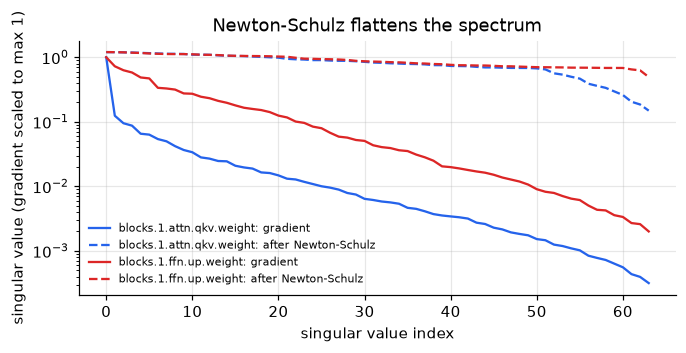

In [12]:
def newton_schulz(G, steps=5):
    """Approximately replace G = U S V^T by U V^T, using only matrix products."""
    a, b, c = 3.4445, -4.7750, 2.0315  # tuned to push singular values towards 1 quickly
    X = G / (G.norm() + 1e-7)  # now every singular value is at most 1
    tall = X.shape[0] > X.shape[1]
    if tall:
        X = X.T  # work with the smaller Gram matrix
    for _ in range(steps):
        A = X @ X.T
        X = a * X + (b * A + c * A @ A) @ X
    return X.T if tall else X


# What it does to a real gradient: one batch through the untrained model.
model = new_model()
x, y = mlexp.get_batch(train_ids, 32, 64, torch.Generator().manual_seed(0))
model(x, y)[1].backward()
fig, ax = plt.subplots(figsize=(7, 3))
for name in ["blocks.1.attn.qkv.weight", "blocks.1.ffn.up.weight"]:
    G = dict(model.named_parameters())[name].grad
    s_g, s_o = torch.linalg.svdvals(G), torch.linalg.svdvals(newton_schulz(G))
    line, = ax.semilogy(s_g / s_g[0], lw=1.5, label=f"{name}: gradient")
    ax.semilogy(s_o, lw=1.5, ls="--", color=line.get_color(), label=f"{name}: after Newton-Schulz")
    print(f"{name:26s} gradient: largest/median singular value {s_g[0] / s_g.median():.0f}   "
          f"after: singular values in [{s_o.min():.2f}, {s_o.max():.2f}], median {s_o.median():.2f}")
ax.set(xlabel="singular value index", ylabel="singular value (gradient scaled to max 1)", title="Newton-Schulz flattens the spectrum")
ax.legend(frameon=False, fontsize=7);

The gradient of the attention projection is dominated by a single direction. After five Newton-Schulz steps most singular values sit between about 0.7 and 1.2. The very smallest are only partly lifted, because five steps of a fixed polynomial cannot reach values that start a thousand times below the largest. That inexactness is deliberate: Jordan et al. (2024) tuned the coefficients for speed rather than precision, and found that it does not hurt training.

In [13]:
class Muon(torch.optim.Optimizer):
    """Momentum for 2-D weights, orthogonalized by Newton-Schulz before each step."""

    def __init__(self, params, lr=0.01, momentum=0.95, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, mu = group["lr"], group["momentum"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                M = self.state[p].setdefault("momentum", torch.zeros_like(p))
                M.mul_(mu).add_(p.grad)
                O = newton_schulz(p.grad + mu * M)  # Nesterov momentum, then orthogonalize
                p.mul_(1 - lr * group["weight_decay"])
                p.add_(O, alpha=-lr * 0.2 * math.sqrt(max(p.shape)))  # match AdamW's update size


class Combined:
    """Drive several optimizers as one (Muon for block matrices, AdamW for the rest)."""

    def __init__(self, *opts):
        self.opts = opts
        self.param_groups = [g for o in opts for g in o.param_groups]

    def zero_grad(self, set_to_none=True):
        for o in self.opts:
            o.zero_grad(set_to_none=set_to_none)

    def step(self):
        for o in self.opts:
            o.step()


def make_muon(model, lr, weight_decay=0.1):
    is_matrix = lambda n, p: p.ndim == 2 and n.startswith("blocks.")
    mats = [p for n, p in model.named_parameters() if is_matrix(n, p)]
    rest = [p for n, p in model.named_parameters() if not is_matrix(n, p)]
    return Combined(Muon(mats, lr=lr, weight_decay=weight_decay), AdamW(rest, lr=lr, weight_decay=weight_decay))

#### Experiment: three optimizers on TinyShakespeare

Comparing optimizers at one shared learning rate would mostly measure which one happens to like that rate. So each optimizer gets a small learning-rate sweep of three values, 200 steps each, and we compare the best run of each. We centred each grid on the optimum found in a wider sweep before writing this chapter; every point printed below comes from this run. SGD gets momentum 0.9 and no weight decay; AdamW and Muon get weight decay 0.1. These are 9 training runs, about four minutes in total.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Each optimizer gets its best of three learning rates and 200 steps. Rank SGD with momentum, AdamW and Muon by final validation loss. Which one is most sensitive to the learning rate?</p><details><summary>Show what happened</summary><p>Muon is best (1.904), then AdamW (2.006), then SGD with momentum (2.175). SGD is by far the most sensitive: at three times its best learning rate it ends at 3.458, while AdamW and Muon lose at most 0.13 anywhere on their tenfold grids.</p></details></div>

In [14]:
sweeps = {
    "SGD + momentum": ([0.3, 1.0, 3.0], lambda m, lr: SGDMomentum(m.parameters(), lr=lr, momentum=0.9)),
    "AdamW": ([0.003, 0.01, 0.03], lambda m, lr: AdamW(m.parameters(), lr=lr, weight_decay=0.1)),
    "Muon": ([0.01, 0.03, 0.1], lambda m, lr: make_muon(m, lr)),
}
sweep_results, best = {}, {}
t_sweep = time.time()
for name, (lrs, make_opt) in sweeps.items():
    for lr in lrs:
        t0 = time.time()
        model = new_model()
        hist = train(model, make_opt(model, lr))
        sweep_results[name, lr] = hist
        print(f"{name:15s} lr {lr:<6g} final val loss {hist['val'][-1]:.3f}   ({time.time() - t0:.0f}s)")
    best_lr = min(lrs, key=lambda lr: np.nan_to_num(sweep_results[name, lr]["val"][-1], nan=99))
    best[name] = (best_lr, sweep_results[name, best_lr])
print(f"sweep took {(time.time() - t_sweep) / 60:.1f} min")

SGD + momentum  lr 0.3    final val loss 2.303   (23s)


SGD + momentum  lr 1      final val loss 2.175   (23s)


SGD + momentum  lr 3      final val loss 3.458   (24s)


AdamW           lr 0.003  final val loss 2.119   (22s)


AdamW           lr 0.01   final val loss 2.006   (23s)


AdamW           lr 0.03   final val loss 2.032   (23s)


Muon            lr 0.01   final val loss 2.000   (26s)


Muon            lr 0.03   final val loss 1.904   (25s)


Muon            lr 0.1    final val loss 2.030   (26s)
sweep took 3.6 min


SGD + momentum  best lr 1   final val loss 2.175
AdamW           best lr 0.01   final val loss 2.006
Muon            best lr 0.03   final val loss 1.904


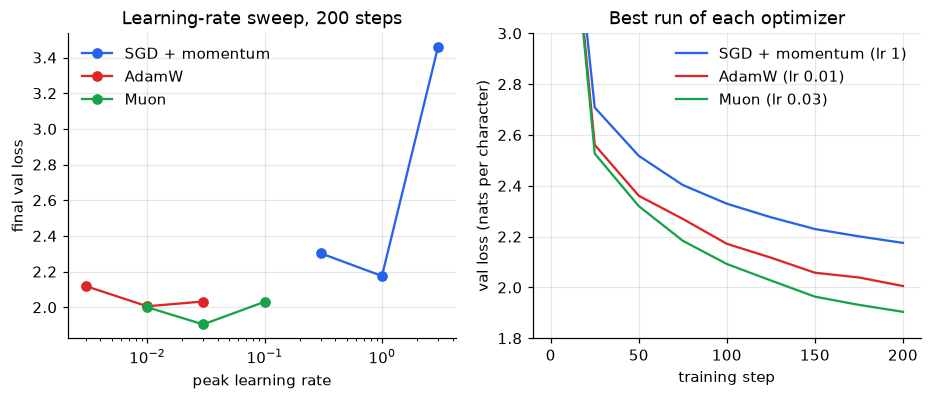

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for name, (lrs, _) in sweeps.items():
    ax1.semilogx(lrs, [sweep_results[name, lr]["val"][-1] for lr in lrs], marker="o", label=name)
ax1.set(xlabel="peak learning rate", ylabel="final val loss", title="Learning-rate sweep, 200 steps")
ax1.legend(frameon=False)
mlexp.plot_histories({f"{n} (lr {lr:g})": h for n, (lr, h) in best.items()}, "Best run of each optimizer", ax=ax2)
ax2.set_ylim(1.8, 3.0)
for name, (lr, hist) in best.items():
    print(f"{name:15s} best lr {lr:g}   final val loss {hist['val'][-1]:.3f}")

#### Why it worked: a post-mortem

**A step size per weight beats one global step size.** AdamW reaches 2.006 against 2.175 for SGD with momentum, and its loss changes by at most 0.11 across a tenfold range of learning rates, while SGD's blows up at three times its best rate. Embeddings, attention, feed-forward weights and norm gains get gradients of very different sizes, and SGD's single step size has to suit the most sensitive of them. **[established]** for Transformers in general, which is why they are almost never trained with plain SGD.

**Muon beats AdamW**, 1.904 against 2.006, with the same learning-rate grid, weight decay and update size per entry. For the block matrices the only change is that the update's singular values are flattened, so the many weak directions in each gradient (we measured the largest singular value at 25 to 172 times the median) get as large a step as the dominant one. That matches the published picture: Muon set records in the NanoGPT training speedrun (Jordan et al., 2024), and Liu et al. (2025) report about twice AdamW's compute efficiency in their scaling experiments. **[likely]** Muon's extra cost is five small matrix products per weight matrix per step; in our tiny model that made each run about 10% slower, at large scale it is reported to be around 1% of the compute. **[likely]**

**Where the per-weight assumption still lives.** Muon only handles the block matrices; the embeddings, output head and norm gains still use AdamW, because a vector or a lookup table has no useful singular directions. Every serious Muon setup we know of is this hybrid. **[established]**

**Caveat on our numbers.** These are 200-step runs of a 200,000-parameter model. The ranking (Muon, AdamW, Lion, SGD with momentum) held in all three seeds we ran, with spreads of 0.02 or less. Optimizer comparisons are notoriously sensitive to tuning, schedule length and scale, and short runs favour whatever optimizer moves fastest early on. The direction of each result matches the published literature, but treat the gaps as illustrations rather than measurements.

### Step 5 (minor): Lion, Shampoo and other recent ideas

Two other recent optimizers fill out the picture.

**Lion** (Chen et al., 2023) was found by an automated search over update rules. It keeps one momentum buffer and steps by its **sign**: every weight moves by exactly `lr` per step, up or down. That is Adam's per-weight normalization pushed to its extreme, with half Adam's memory, since there is no second average. Because every step has full size, Lion needs a learning rate 3 to 10 times smaller than AdamW's. **[established]** The authors report gains over AdamW on vision and language models; later independent comparisons found the gap small once both are tuned. **[likely]**

**Shampoo** (Gupta et al., 2018) is the full-matrix cousin of Adam. For each weight matrix it keeps running averages of `\(GG^\top\)` and `\(G^\top G\)` and multiplies the gradient on both sides by their inverse fourth roots. That is a preconditioner per layer that, unlike Adam's, can undo curvature that is not aligned with the axes, at the cost of extra memory and periodic matrix roots. A distributed version of Shampoo won the external-tuning track of the AlgoPerf training-speed benchmark in 2024. **[likely]** With its averages switched off, Shampoo's update becomes exactly `\(UV^\top\)`: Muon can be read as Shampoo without memory. **[established]**

In [16]:
class Lion(torch.optim.Optimizer):
    """Lion: step by the sign of an interpolated momentum, one size for every weight."""

    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            (b1, b2), lr = group["betas"], group["lr"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                m = self.state[p].setdefault("m", torch.zeros_like(p))
                p.mul_(1 - lr * group["weight_decay"])
                p.add_(torch.sign(m.lerp(p.grad, 1 - b1)), alpha=-lr)  # every weight moves by lr
                m.lerp_(p.grad, 1 - b2)


model = new_model()
lion_hist = train(model, Lion(model.parameters(), lr=0.003, weight_decay=0.1))
print(f"Lion (lr {0.003})  final val loss {lion_hist['val'][-1]:.3f}")
for name, (lr, hist) in best.items():
    print(f"{name:15s} best lr {lr:g}   final val loss {hist['val'][-1]:.3f}")

Lion (lr 0.003)  final val loss 2.112
SGD + momentum  best lr 1   final val loss 2.175
AdamW           best lr 0.01   final val loss 2.006
Muon            best lr 0.03   final val loss 1.904


Lion, at a third of AdamW's best learning rate, reaches 2.112: better than SGD with momentum, worse than AdamW and Muon. We gave it only one learning rate here (the best of five in a wider 250-step sweep we ran while writing), so treat this as a rough placement, not a verdict. Chen et al. (2023) found that Lion's advantage grows with batch size, and our batches of 32 sequences are small. **[likely]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| Adam, no decay | 2.007 | 2.017 ± 0.012 | 2.007 / 2.031 / 2.013 |
| Adam + L2, λ=0.001 | 2.155 | 2.196 ± 0.038 | 2.155 / 2.231 / 2.202 |
| AdamW, λ=0.1 | 2.006 | 2.013 ± 0.006 | 2.006 / 2.016 / 2.018 |
| SGD + momentum, best lr | 2.175 | 2.197 ± 0.019 | 2.175 / 2.204 / 2.211 |
| AdamW, best lr | 2.006 | 2.013 ± 0.006 | 2.006 / 2.016 / 2.018 |
| Muon, best lr | 1.904 | 1.912 ± 0.013 | 1.904 / 1.905 / 1.927 |
| Lion | 2.112 | 2.104 ± 0.008 | 2.112 / 2.103 / 2.097 |

The ranking held in every seed, and so did the cost of L2 regularization inside Adam.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Explain why plain SGD zig-zags in a narrow valley and how momentum fixes it.</li><li>Write SGD with momentum, Adam, AdamW and Muon from scratch, each in under 25 lines.</li><li>Say when Adam's per-weight scaling helps (steep directions aligned with weights) and when it does not (directions that mix weights, decay added to the gradient).</li><li>Describe what Newton-Schulz orthogonalization does to the spectrum of a gradient matrix, and why that makes Muon independent of the basis.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why does turning the valley by 45° change Adam's result but not momentum's?</summary><p>Momentum's update is built only from the gradient vector, which turns with the valley, so the whole run just turns with it. Adam divides each coordinate separately by its own gradient scale. Aligned, the coordinates are the steep and flat directions, so the division equalizes them. Turned, every coordinate mixes steep and flat, and the division no longer separates them.</p></details><details><summary>With Adam + L2, why can a weight with a tiny loss gradient be pulled towards zero at about lr per step, whatever the value of λ?</summary><p>Its total gradient is almost entirely the penalty term λw. Adam divides by the RMS of that same term, so the step is about lr times the sign of w. The size of λ cancels out. AdamW instead shrinks w by the fraction lr·λ, which does depend on λ.</p></details><details><summary>If a gradient matrix is G = U Σ V<sup>T</sup>, what does Muon step along, and why does that help the small singular directions?</summary><p>Along U V<sup>T</sup>: the same directions, with every singular value set to one. A plain gradient step would move the small singular directions by a tiny amount compared with the dominant one; after orthogonalization they all move by the same amount.</p></details><details><summary>Why did we give each optimizer its own learning-rate sweep instead of one shared rate?</summary><p>Different optimizers have very different natural step sizes: SGD's depends on the gradient's size, Adam's and Muon's do not, and Lion's must be smaller again. At one shared rate the comparison would mostly measure which optimizer that rate happens to suit.</p></details></div>

## Further reading

- Polyak, 1964, [Some methods of speeding up the convergence of iteration methods](https://doi.org/10.1016/0041-5553(64)90137-5): heavy-ball momentum.
- Duchi, Hazan and Singer, 2011, [Adaptive Subgradient Methods for Online Learning and Stochastic Optimization](https://jmlr.org/papers/v12/duchi11a.html): AdaGrad.
- Kingma and Ba, 2014, [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980).
- Loshchilov and Hutter, 2017, [Decoupled Weight Decay Regularization](https://arxiv.org/abs/1711.05101): AdamW.
- Gupta, Koren and Singer, 2018, [Shampoo: Preconditioned Stochastic Tensor Optimization](https://arxiv.org/abs/1802.09568).
- Chen et al., 2023, [Symbolic Discovery of Optimization Algorithms](https://arxiv.org/abs/2302.06675): Lion.
- Jordan et al., 2024, [Muon: An optimizer for hidden layers in neural networks](https://kellerjordan.github.io/posts/muon/).
- Liu et al., 2025, [Muon is Scalable for LLM Training](https://arxiv.org/abs/2502.16982).